In [ ]:
!pip install transformers datasets accelerate scikit-learn scipy

In [ ]:
import pandas as pd

df = pd.read_csv("mentalmanip_en.csv")

# Keep only manipulative
df = df[df["Manipulative"] == 1]

df.head()

,ID,Dialogue,Manipulative,Technique,Vulnerability
0,85514414,"Person1: Jesus! Listen to this one: ""Do you re...",1,NaN,NaN
1,85514415,Person1: I don't know.\nPerson2: Don't go.\nPe...,1,Rationalization,NaN
2,85514416,"Person1: You're mine, you know. I made you.\n...",1,"Persuasion or Seduction,Accusation",Dependency
3,85514417,Person1: All right. Tell 'em to shoot to kill....,1,"Shaming or Belittlement,Intimidation",NaN
4,85514418,Person1: You're alive! She didn't kill you!\nP...,1,Persuasion or Seduction,NaN


In [ ]:
def map_emotion(techniques):
    if pd.isna(techniques):
        return None

    t = techniques.lower()

    if any(x in t for x in ["victim", "servant"]):
        return "guilt"
    elif any(x in t for x in ["shaming", "accusation"]):
        return "shame"
    elif any(x in t for x in ["intimidation", "anger"]):
        return "threat"
    elif "persuasion" in t or "seduction" in t:
        return "flattery"
    else:
        return None  # drop others

df["emotion"] = df["Technique"].apply(map_emotion)

# Drop rows with None
df = df.dropna(subset=["emotion"])

df["emotion"].value_counts()

,count
emotion,
shame,737
flattery,638
threat,386
guilt,109


In [ ]:
label_map = {
    "guilt": 0,
    "shame": 1,
    "threat": 2,
    "flattery": 3
}

df["label"] = df["emotion"].map(label_map)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, stratify=df["label"])

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df[["Dialogue", "label"]])
val_ds = Dataset.from_pandas(val_df[["Dialogue", "label"]])

def tokenize(example):
    return tokenizer(example["Dialogue"], truncation=True, padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)

Map:   0%|          | 0/1683 [00:00<?, ? examples/s]

Map:   0%|          | 0/187 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=4
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./emotion_model",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=True,
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,1.269881
2,No log,1.202205
3,1.196926,1.169228


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=633, training_loss=1.1562416835983782, metrics={'train_runtime': 315.8458, 'train_samples_per_second': 15.986, 'train_steps_per_second': 2.004, 'total_flos': 332117893426176.0, 'train_loss': 1.1562416835983782, 'epoch': 3.0})

In [ ]:
df_multi = pd.read_csv("mentalmanip_master.csv")

df_multi.head()

,ID,dialogue_en,dialogue_hi_latn,dialogue_te_latn,dialogue_ta_latn
0,85514414,"Person1: Jesus! Listen to this one: ""Do you re...","Person1: yishu! ise suno: ""kya tum mujhe yaad ...","Person 1: yesu! idi vinandi: ""miru nannu gurtu...","Person1: yesu! idhai kelungal: ""ennai ninaivir..."
1,85514415,Person1: I don't know. Person2: Don't go. Pers...,Person1: mujhe nahi pataa\nPerson2: mat jaao\n...,Person 1: naku teliyadu.\nPerson 2: vellavaddu...,Person1: enakku theriyaathu.\nPerson2: poga ve...
2,85514416,"Person1: You're mine, you know. I made you. P...","Person1: tum mere ho, tumhe pata hai maine tu...","Person 1: miru naavaru, meeku telusu. ninnu t...","Person1: nee ennudaiyavan, unakku theriyum. n..."
3,85514417,Person1: All right. Tell 'em to shoot to kill....,Person1: theek hai unhen marane ke lie goli ma...,Person 1: sare. kalchi champamani cheppandi.\n...,Person1: sari. kolla suda sollunga.\nPerson2: ...
4,85514418,Person1: You're alive! She didn't kill you! Pe...,Person1: op jeevit hain! usne tumhe nahi mara!...,Person 1: miru batike unnaru! aame ninnu champ...,Person1: neengal uyirudan irukkireergal! aval ...


In [ ]:
import torch
import torch.nn.functional as F

def get_probs(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to("cuda")
    outputs = model(**inputs)
    probs = F.softmax(outputs.logits, dim=1)
    return probs.detach().cpu().numpy()[0]

In [ ]:
model.to("cuda")

results = []

for _, row in df_multi.iterrows():
    p_eng = get_probs(row["dialogue_en"])
    p_hin = get_probs(row["dialogue_hi_latn"])
    p_tel = get_probs(row["dialogue_te_latn"])
    p_tam = get_probs(row["dialogue_ta_latn"])

    results.append((p_eng, p_hin, p_tel, p_tam))

In [ ]:
from scipy.spatial.distance import jensenshannon
import numpy as np

jsd_hin, jsd_tel, jsd_tam = [], [], []

for p_eng, p_hin, p_tel, p_tam in results:
    jsd_hin.append(jensenshannon(p_eng, p_hin))
    jsd_tel.append(jensenshannon(p_eng, p_tel))
    jsd_tam.append(jensenshannon(p_eng, p_tam))

print("Hindi Drift:", np.mean(jsd_hin))
print("Telugu Drift:", np.mean(jsd_tel))
print("Tamil Drift:", np.mean(jsd_tam))

Hindi Drift: 0.21296264
Telugu Drift: 0.26851493
Tamil Drift: 0.25570926


In [ ]:
def entropy(p):
    return -np.sum(p * np.log(p + 1e-9))

entropies = [entropy(p[0]) for p in results]  # English

print("Avg Entropy:", np.mean(entropies))

Avg Entropy: 0.93398017


In [ ]:
dialogue_jsd_df = pd.DataFrame({
    'ID': df_multi['ID'],
    'jsd_english_hindi': jsd_hin,
    'jsd_english_telugu': jsd_tel,
    'jsd_english_tamil': jsd_tam
})

print("JSD values for each dialogue:")
display(dialogue_jsd_df.head())

JSD values for each dialogue:


,ID,jsd_english_hindi,jsd_english_telugu,jsd_english_tamil
0,85514414,0.027927,0.245707,0.084207
1,85514415,0.105896,0.097700,0.040132
2,85514416,0.106789,0.197957,0.277484
3,85514417,0.266961,0.107278,0.177213
4,85514418,0.393732,0.385389,0.226239


In [ ]:
dialogue_jsd_df.to_csv('dialogue_jsd_values.csv', index=False)
print("JSD values for each dialogue saved to dialogue_jsd_values.csv")

JSD values for each dialogue saved to dialogue_jsd_values.csv


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

def evaluate_model(trainer, dataset):
    preds_output = trainer.predict(dataset)

    preds = np.argmax(preds_output.predictions, axis=1)
    labels = preds_output.label_ids

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_per_class = f1_score(labels, preds, average=None)

    print("Accuracy:", acc)
    print("Macro F1:", f1_macro)
    print("F1 per class:", f1_per_class)

    print("\nClassification Report:\n")
    print(classification_report(labels, preds))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(labels, preds))

# Run evaluation
evaluate_model(trainer, val_ds)

Accuracy: 0.49732620320855614
Macro F1: 0.3808498095410847
F1 per class: [0.         0.53691275 0.48648649 0.5       ]

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.53      0.54      0.54        74
           2       0.50      0.47      0.49        38
           3       0.46      0.55      0.50        64

    accuracy                           0.50       187
   macro avg       0.37      0.39      0.38       187
weighted avg       0.47      0.50      0.48       187


Confusion Matrix:

[[ 0  4  0  7]
 [ 0 40 13 21]
 [ 0  7 18 13]
 [ 0 24  5 35]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
trainer.save_model("emotion_model_final")
tokenizer.save_pretrained("emotion_model_final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('emotion_model_final/tokenizer_config.json',
 'emotion_model_final/tokenizer.json')

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("emotion_model_final")
model = AutoModelForSequenceClassification.from_pretrained("emotion_model_final")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=4, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [ ]:
import torch.nn.functional as F

def get_probs(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)
    return probs.cpu().numpy()[0]

In [ ]:
import pandas as pd

df_multi = pd.read_csv("mentalmanip_master.csv")
df_multi.head()

,ID,dialogue_en,dialogue_hi_latn,dialogue_te_latn,dialogue_ta_latn
0,85514414,"Person1: Jesus! Listen to this one: ""Do you re...","Person1: yishu! ise suno: ""kya tum mujhe yaad ...","Person 1: yesu! idi vinandi: ""miru nannu gurtu...","Person1: yesu! idhai kelungal: ""ennai ninaivir..."
1,85514415,Person1: I don't know. Person2: Don't go. Pers...,Person1: mujhe nahi pataa\nPerson2: mat jaao\n...,Person 1: naku teliyadu.\nPerson 2: vellavaddu...,Person1: enakku theriyaathu.\nPerson2: poga ve...
2,85514416,"Person1: You're mine, you know. I made you. P...","Person1: tum mere ho, tumhe pata hai maine tu...","Person 1: miru naavaru, meeku telusu. ninnu t...","Person1: nee ennudaiyavan, unakku theriyum. n..."
3,85514417,Person1: All right. Tell 'em to shoot to kill....,Person1: theek hai unhen marane ke lie goli ma...,Person 1: sare. kalchi champamani cheppandi.\n...,Person1: sari. kolla suda sollunga.\nPerson2: ...
4,85514418,Person1: You're alive! She didn't kill you! Pe...,Person1: op jeevit hain! usne tumhe nahi mara!...,Person 1: miru batike unnaru! aame ninnu champ...,Person1: neengal uyirudan irukkireergal! aval ...


In [ ]:
results = []

for _, row in df_multi.iterrows():
    p_eng = get_probs(row["dialogue_en"])
    p_hin = get_probs(row["dialogue_hi_latn"])
    p_tel = get_probs(row["dialogue_te_latn"])
    p_tam = get_probs(row["dialogue_ta_latn"])

    results.append((p_eng, p_hin, p_tel, p_tam))

In [ ]:
conf_eng = [max(p[0]) for p in results]
print("Avg confidence:", np.mean(conf_eng))

Avg confidence: 0.63934344


/tmp/ipykernel_1553/907090856.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([jsd_hin, jsd_tel, jsd_tam], labels=["Hindi", "Telugu", "Tamil"])


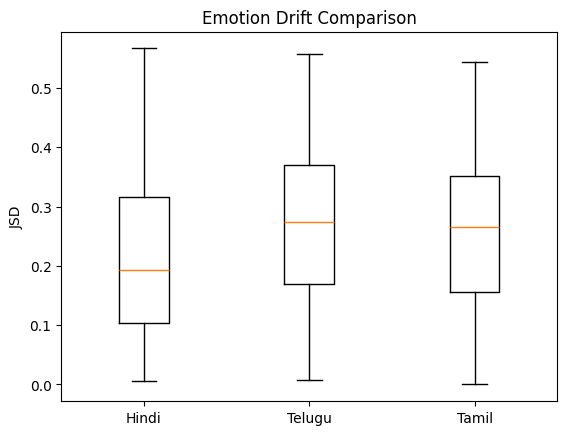

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot([jsd_hin, jsd_tel, jsd_tam], labels=["Hindi", "Telugu", "Tamil"])
plt.title("Emotion Drift Comparison")
plt.ylabel("JSD")
plt.show()

In [ ]:
dialogue_jsd_df = pd.DataFrame({
    'ID': df_multi['ID'],
    'jsd_english_hindi': jsd_hin,
    'jsd_english_telugu': jsd_tel,
    'jsd_english_tamil': jsd_tam
})

In [ ]:
df_combined = df_jsd.merge(df_phase1, on="ID")

NameError: name 'df_jsd' is not defined

In [ ]:
df_emotion_drift = pd.DataFrame({
    "ID": df_multi["ID"],
    "jsd_hindi": jsd_hin,
    "jsd_telugu": jsd_tel,
    "jsd_tamil": jsd_tam
})

In [ ]:
df_emotion_drift.to_csv("emotion_drift_results.csv", index=False)

In [ ]:
df_emotion_drift["avg_drift"] = (
    df_emotion_drift["jsd_hindi"] +
    df_emotion_drift["jsd_telugu"] +
    df_emotion_drift["jsd_tamil"]
) / 3

high_drift = df_emotion_drift.sort_values("avg_drift", ascending=False).head(10)
print(high_drift)

            ID  jsd_hindi  jsd_telugu  jsd_tamil  avg_drift
2326  85517132   0.533514    0.527026   0.494888   0.518476
1833  85516258   0.507924    0.484321   0.527798   0.506681
2285  85517091   0.563835    0.468020   0.476173   0.502676
2464  85517294   0.523992    0.511750   0.450220   0.495321
1881  85516306   0.535753    0.510660   0.434718   0.493710
3144  85518329   0.531715    0.464955   0.476097   0.490923
3421  85518607   0.537826    0.506897   0.427060   0.490594
1290  85515715   0.523509    0.522027   0.416504   0.487347
1624  85516049   0.530468    0.490516   0.437539   0.486174
2433  85517263   0.489560    0.464244   0.501617   0.485140


In [ ]:
import numpy as np

p_eng_all = np.array([r[0] for r in results])
p_hin_all = np.array([r[1] for r in results])
p_tel_all = np.array([r[2] for r in results])
p_tam_all = np.array([r[3] for r in results])

print("Avg ENG probs:", np.mean(p_eng_all, axis=0))
print("Avg TEL probs:", np.mean(p_tel_all, axis=0))

Avg ENG probs: [0.04073539 0.41902217 0.1877572  0.35248533]
Avg TEL probs: [0.03826359 0.4651411  0.32371885 0.17287655]


In [ ]:
print("Avg HIN probs:", np.mean(p_hin_all, axis=0))
print("Avg TAM probs:", np.mean(p_tam_all, axis=0))

Avg HIN probs: [0.03799167 0.5582981  0.2057732  0.19793713]
Avg TAM probs: [0.04192065 0.38031152 0.34353492 0.23423363]


In [ ]:
high_drift_text = df_multi.merge(high_drift, on="ID")
print(high_drift_text[["ID", "dialogue_en"]].head())

         ID                                        dialogue_en
0  85515715  Person1: Look, we have to get these... Person2...
1  85516049  Person1: You killed Domini, didn't you, witch?...
2  85516258  Person1: My lady VIOLA. Person2: Lord Wessex. ...
3  85516306  Person1: You want the tapes for yourself.     ...
4  85517091  Person1: Recognize this? How would you like yo...


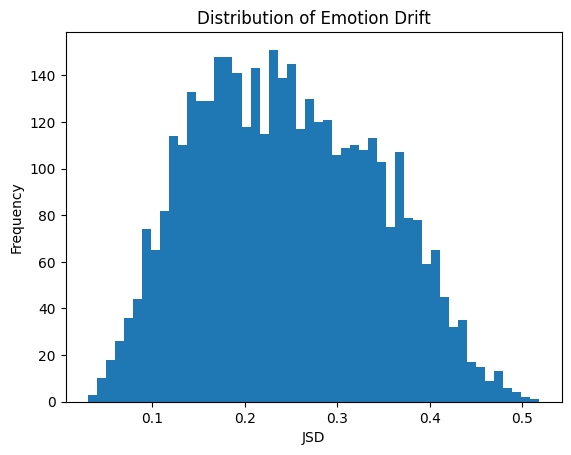

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_emotion_drift["avg_drift"], bins=50)
plt.title("Distribution of Emotion Drift")
plt.xlabel("JSD")
plt.ylabel("Frequency")
plt.show()